# Section 4.4 — Tool robustness analysis

This notebook reconstructs the robustness comparison used in the paper's Section `4.4` discussion directly from the released `results/` directories.

Running all cells will:
- load the high-robustness and low-robustness experiment bundles for every dataset, planner, and backbone model
- compute the accuracy change when robustness is reduced
- reproduce the table-style view used in the paper discussion and a heatmap for quick visual inspection

No intermediate CSV files are required.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from notebooks.posthoc_results import (
    DATASET_LABEL_ORDER,
    MODEL_ORDER,
    PLANNER_ORDER,
    load_episode_results,
)

sns.set_theme(style="whitegrid", context="talk")
episodes = load_episode_results(include_steps=False)
episodes.head()

,dataset,dataset_label,planner,model,robustness,robustness_label,run_id,result_dir,question_id,question_text,final_output,success,evaluation_label,is_correct,total_steps,repetitive_count
0,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0000,What country does University of Oxford's head...,England,True,correct,True,4,0
1,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0001,At which street address did the death of Anne ...,No street address information is available for...,True,refusal/unsure,False,20,0
2,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0002,Tell me when Lon Chaney Jr. was born.,1906-02-10,True,correct,True,3,0
3,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0003,What is Chris Elliott's birth date?,1960-05-31,True,correct,True,3,0
4,kqa_pro,KQA Pro,FH,GPT-4.1-mini,high,High robustness,2026-01-06-22-16-13,pne.gpt-4p1-mini.json.v1.retries-8,val_0004,"Which covers a larger amount of area, Key West...",Billings,True,correct,True,4,0


In [5]:
accuracy_by_run = (
    episodes.groupby(
        ["dataset", "dataset_label", "planner", "model", "robustness", "run_id"]
    )
    .agg(accuracy=("is_correct", "mean"))
    .reset_index()
)

accuracy_summary = (
    accuracy_by_run.pivot_table(
        index=["dataset", "dataset_label", "planner", "model"],
        columns="robustness",
        values="accuracy",
        observed=False,
    )
    .reset_index()
)
accuracy_summary["delta_accuracy"] = (
    accuracy_summary["low"] - accuracy_summary["high"]
)

accuracy_summary["dataset_label"] = pd.Categorical(
    accuracy_summary["dataset_label"],
    categories=DATASET_LABEL_ORDER,
    ordered=True,
)
accuracy_summary["model"] = pd.Categorical(
    accuracy_summary["model"],
    categories=MODEL_ORDER,
    ordered=True,
)
accuracy_summary["planner"] = pd.Categorical(
    accuracy_summary["planner"],
    categories=PLANNER_ORDER,
    ordered=True,
)

accuracy_summary = accuracy_summary.sort_values(
    ["dataset_label", "model", "planner"]
)

paper_table = accuracy_summary.pivot_table(
    index=["dataset_label", "model"],
    columns="planner",
    values="delta_accuracy",
    observed=False,
)
paper_table.style.format("{:+.3f}")

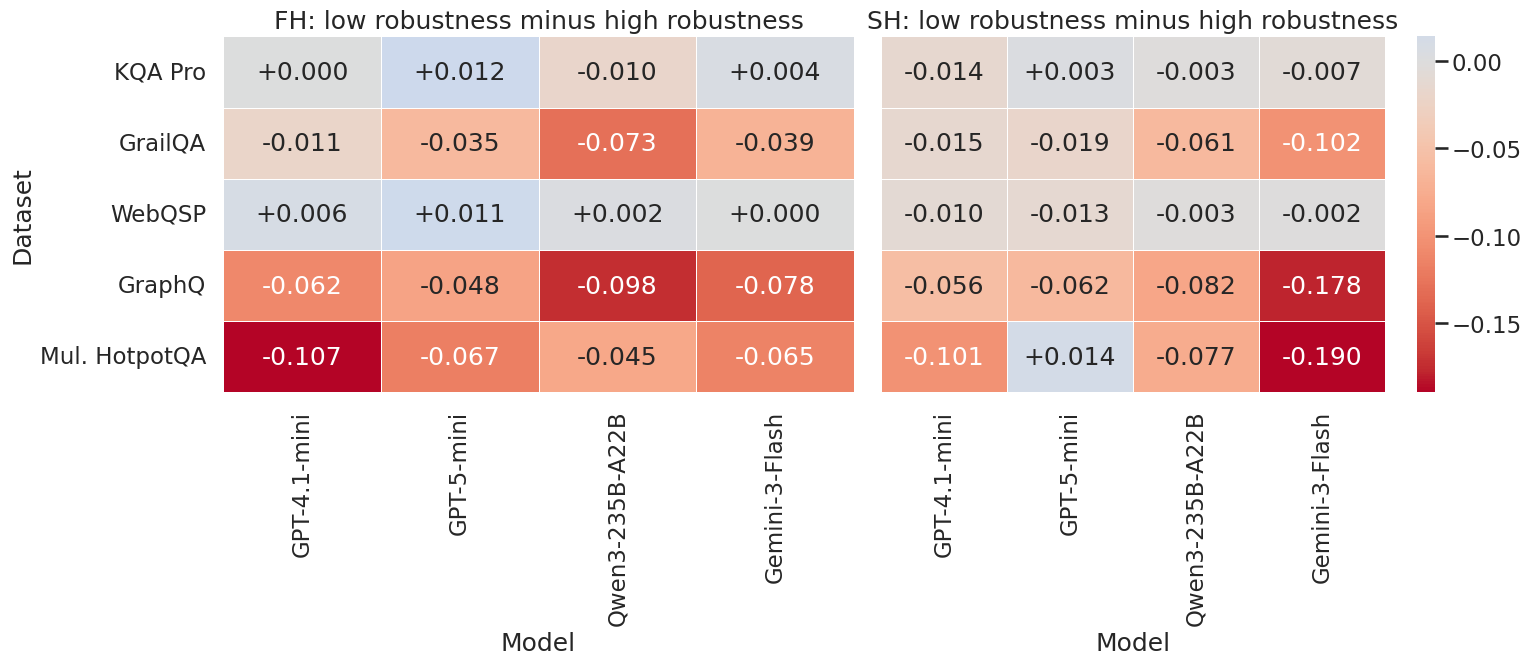

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for axis, planner in zip(axes, PLANNER_ORDER):
    planner_frame = accuracy_summary[accuracy_summary["planner"] == planner]
    heatmap_data = planner_frame.pivot(
        index="dataset_label",
        columns="model",
        values="delta_accuracy",
    ).loc[DATASET_LABEL_ORDER, MODEL_ORDER]

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt="+.3f",
        cmap="coolwarm_r",
        center=0.0,
        linewidths=0.5,
        cbar=planner == PLANNER_ORDER[-1],
        ax=axis,
    )
    axis.set_title(f"{planner}: low robustness minus high robustness")
    axis.set_xlabel("Model")
    if axis is axes[0]:
        axis.set_ylabel("Dataset")
    else:
        axis.set_ylabel("")

plt.tight_layout()

In [6]:
planner_gap = (
    accuracy_summary.pivot_table(
        index=["dataset_label", "model"],
        columns="planner",
        values="delta_accuracy",
        observed=False,
    )
    .reset_index()
)
planner_gap["sh_minus_fh_delta"] = planner_gap["SH"] - planner_gap["FH"]
planner_gap.sort_values("sh_minus_fh_delta").style.format(
    {
        "FH": "{:+.3f}",
        "SH": "{:+.3f}",
        "sh_minus_fh_delta": "{:+.3f}",
    }
)

planner,dataset_label,model,FH,SH,sh_minus_fh_delta
19,Mul. HotpotQA,Gemini-3-Flash,-0.065,-0.190,-0.125
15,GraphQ,Gemini-3-Flash,-0.078,-0.178,-0.101
7,GrailQA,Gemini-3-Flash,-0.039,-0.102,-0.063
18,Mul. HotpotQA,Qwen3-235B-A22B,-0.045,-0.077,-0.032
9,WebQSP,GPT-5-mini,+0.011,-0.013,-0.024
8,WebQSP,GPT-4.1-mini,+0.006,-0.010,-0.016
0,KQA Pro,GPT-4.1-mini,+0.000,-0.014,-0.014
13,GraphQ,GPT-5-mini,-0.048,-0.062,-0.014
3,KQA Pro,Gemini-3-Flash,+0.004,-0.007,-0.011
1,KQA Pro,GPT-5-mini,+0.012,+0.003,-0.009


## How this supports Section 4.4

- Negative values mean accuracy fell when robustness was reduced.
- The main pattern from the paper is visible here: both planners usually degrade by similar amounts, with no consistent `SH` advantage.
- The clearest exceptions are the `Gemini-3-Flash` `SH` runs on `GraphQ` and `Mul. HotpotQA`, where the drop is notably larger than `FH`.
- Because the notebook reads the released run directories directly, it stays reproducible without relying on precomputed CSV files.